In [2]:
import sys

sys.path.append("../../../")

from tqdm.auto import tqdm

from coqui.TTS.api import TTS
from src.file_repository import FileRepository
import os
from src.utils.ml_processing.lang2code_mapper import map_language_to_code
from utils import add_pauses, merge_speaker_files

[2025-04-12 02:54:06,673] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/opt/anaconda/envs/video_project_2/compiler_compat/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Load vocos from local path ./models_weights/vocos-mel-24khz


FileNotFoundError: [Errno 2] No such file or directory: './models_weights/vocos-mel-24khz/config.yaml'

In [3]:
class XTTSClient:
    def __init__(
        self,
        file_repository: FileRepository,
        tts_model_path="../../../models_weights/xtts_model/tts_models/multilingual/multi-dataset/xtts_v2",
        device="cuda",
    ):
        self.device = device

        self.tts_model_path = os.path.abspath(tts_model_path)
        self.config_path = os.path.join(tts_model_path, "config.json")

        self._file_repository = file_repository

        self.model = None
        self.load_models()

    def load_models(self):
        self.model = TTS(model_path=self.tts_model_path, config_path=self.config_path).to(self.device)

    def __enter__(self):
        self.load_models()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        self.model = None

    def generate_audio(
        self, text: str, source_audio_path: str, save_path: str, language: str
    ):
        """
        Generates audio without voice conversion.
        """
        self.model.tts_to_file(
            text=text,
            file_path=save_path,
            speaker_wav=source_audio_path,
            language=language,
            enable_text_splitting=False,
            repetition_penalty=2.0,
        )

    def tts_pipeline(self, video_translation, temp_folder, language="en"):
        language = map_language_to_code(language, "whisper")

        for idx, segment in enumerate(
            tqdm(
                video_translation.translated_texts,
                desc="Voice generation pipeline.",
                leave=True,
            )
        ):  
            file_path = os.path.join(temp_folder, f"{segment.start}_{segment.end}.wav")
            if not os.path.exists(file_path):
                source_file = segment.source_file
                if segment.end - segment.start < 4:
                    source_file_updated = segment.source_file.replace(".wav", "_extended.wav")
                    merge_speaker_files(video_translation,
                                    segment.speaker,
                                    idx,
                                    source_file_updated
                                    )
                    source_file = source_file_updated
                else:
                    add_pauses(segment.source_file)
            
                self.generate_audio(
                    segment.translation, source_file, file_path, language
                )
                
            video_translation.translated_texts[idx].generated_file = file_path
        return video_translation

In [6]:
tts_model_path="../../../models_weights/xtts_model/tts_models/multilingual/multi-dataset/xtts_v2"
config_path = os.path.join(tts_model_path, "config.json")

In [7]:
model = TTS(
    model_path=tts_model_path, 
    config_path=config_path)

/opt/anaconda/envs/video_project_2/lib/python3.10/site-packages/trainer/io.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=map_locatio

In [11]:
from IPython.display import display, Audio

In [15]:
text="In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling."
save_path="output.wav"
source_audio_path="../../../data/350eb556-bf0d-4d9b-b415-5e9520859189/background_files/vocals.wav"
language = "en"

In [22]:
model.tts_to_file(
            text=text,
            speed=0.25,
            file_path=save_path,
            speaker_wav=source_audio_path,
            language=language,
            enable_text_splitting=False,
            repetition_penalty=2.0,
        )

'output.wav'

In [17]:
Audio("output.wav")

In [19]:
Audio("output.wav")

In [21]:
Audio("output.wav")

In [23]:
Audio("output.wav")

In [35]:
from scipy.io import wavfile
import torchaudio
from tqdm.auto import tqdm

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
from IPython.display import clear_output

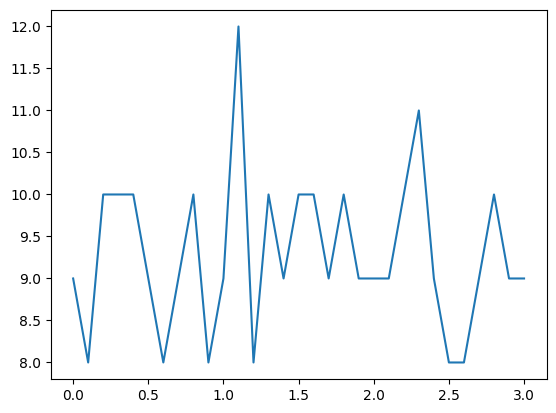

In [88]:
speeds = np.linspace(0.0, 3.0, num=3*10+1)
audio_lens = []
for speed_param in tqdm(speeds):
    model.tts_to_file(
            text=text,
            speed=speed_param,
            file_path=save_path,
            speaker_wav=source_audio_path,
            language=language,
            enable_text_splitting=False,
            repetition_penalty=2.0,
        )
    audio_len = torchaudio.info('output.wav').num_frames//24000
    audio_lens.append(audio_len)
    clear_output(wait=True)
    
    plt.figure()
    plt.plot(speeds[:len(audio_lens)], audio_lens)
    plt.show()

In [ ]:

# Example: Clearing output dynamically
for i in range(5):
    print(f"Current iteration: {i}")
    clear_output(wait=True)  # Clears output before printing the next one


In [89]:
from coqui.TTS import tts

In [ ]:
from coqui.TTS.tts.models.xtts import Xtts, 

In [101]:
from pathlib import Path

In [91]:
from TTS.tts.configs.xtts_config import XttsConfig
from TTS.tts.models.xtts import Xtts

In [97]:
!ls "../../../models_weights/xtts_model/tts_models/multilingual/multi-dataset/xtts_v2/"

config.json  hash.md5  model.pth  speakers_xtts.pth  tos_agreed.txt  vocab.json


In [95]:
config = XttsConfig()
model = Xtts.init_from_config(config)
# model.load_checkpoint(config, checkpoint_dir=tts_model_path, eval=True)

In [107]:
from TTS.tts.layers.xtts.xtts_manager import LanguageManager, SpeakerManager
from TTS.tts.layers.xtts.tokenizer import VoiceBpeTokenizer, split_sentence

In [110]:
def load_checkpoint(
        self,
        config,
        checkpoint_dir=None,
        checkpoint_path=None,
        vocab_path=None,
        eval=True,
        strict=True,
        use_deepspeed=False,
        speaker_file_path=None,
    ):
        """
        Loads a checkpoint from disk and initializes the model's state and tokenizer.

        Args:
            config (dict): The configuration dictionary for the model.
            checkpoint_dir (str, optional): The directory where the checkpoint is stored. Defaults to None.
            checkpoint_path (str, optional): The path to the checkpoint file. Defaults to None.
            vocab_path (str, optional): The path to the vocabulary file. Defaults to None.
            eval (bool, optional): Whether to set the model to evaluation mode. Defaults to True.
            strict (bool, optional): Whether to strictly enforce that the keys in the checkpoint match the keys in the model. Defaults to True.

        Returns:
            None
        """

        model_path = checkpoint_path or os.path.join(checkpoint_dir, "model.pth")
        if vocab_path is None:
            if checkpoint_dir is not None and (Path(checkpoint_dir) / "vocab.json").is_file():
                vocab_path = str(Path(checkpoint_dir) / "vocab.json")
            else:
                vocab_path = config.model_args.tokenizer_file

        if speaker_file_path is None and checkpoint_dir is not None:
            speaker_file_path = os.path.join(checkpoint_dir, "speakers_xtts.pth")

        self.language_manager = LanguageManager(config)
        self.speaker_manager = None
        if speaker_file_path is not None and os.path.exists(speaker_file_path):
            self.speaker_manager = SpeakerManager(speaker_file_path)

        if os.path.exists(vocab_path):
            self.tokenizer = VoiceBpeTokenizer(vocab_file=vocab_path)

        self.init_models()

        checkpoint = self.get_compatible_checkpoint_state_dict(model_path)

        # deal with v1 and v1.1. V1 has the init_gpt_for_inference keys, v1.1 do not
        try:
            self.load_state_dict(checkpoint, strict=strict)
        except:
            if eval:
                self.gpt.init_gpt_for_inference(kv_cache=self.args.kv_cache)
            self.load_state_dict(checkpoint, strict=strict)

#         if eval:
#             self.hifigan_decoder.eval()
#             self.gpt.init_gpt_for_inference(kv_cache=self.args.kv_cache, use_deepspeed=use_deepspeed)
#             self.gpt.eval()

In [111]:
load_checkpoint(model, config=config, checkpoint_dir=tts_model_path, eval=True)

RuntimeError: Error(s) in loading state_dict for Xtts:
	Missing key(s) in state_dict: "gpt.gpt.wte.weight", "gpt.prompt_embedding.weight", "gpt.prompt_pos_embedding.emb.weight", "gpt.gpt_inference.transformer.h.0.ln_1.weight", "gpt.gpt_inference.transformer.h.0.ln_1.bias", "gpt.gpt_inference.transformer.h.0.attn.c_attn.weight", "gpt.gpt_inference.transformer.h.0.attn.c_attn.bias", "gpt.gpt_inference.transformer.h.0.attn.c_proj.weight", "gpt.gpt_inference.transformer.h.0.attn.c_proj.bias", "gpt.gpt_inference.transformer.h.0.ln_2.weight", "gpt.gpt_inference.transformer.h.0.ln_2.bias", "gpt.gpt_inference.transformer.h.0.mlp.c_fc.weight", "gpt.gpt_inference.transformer.h.0.mlp.c_fc.bias", "gpt.gpt_inference.transformer.h.0.mlp.c_proj.weight", "gpt.gpt_inference.transformer.h.0.mlp.c_proj.bias", "gpt.gpt_inference.transformer.h.1.ln_1.weight", "gpt.gpt_inference.transformer.h.1.ln_1.bias", "gpt.gpt_inference.transformer.h.1.attn.c_attn.weight", "gpt.gpt_inference.transformer.h.1.attn.c_attn